# Linear Regression Analysis (Python)

This notebook loads salary data, visualizes the relationship between years of experience and salary, fits a linear regression model, overlays the regression line on a scatter plot, and evaluates model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("regression_data.csv")

print("First rows:")
print(df.head())
print(f"\nShape: {df.shape}")
print("\nColumn types:")
print(df.dtypes)

First rows:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Shape: (10, 2)

Column types:
YearsExperience    float64
Salary             float64
dtype: object


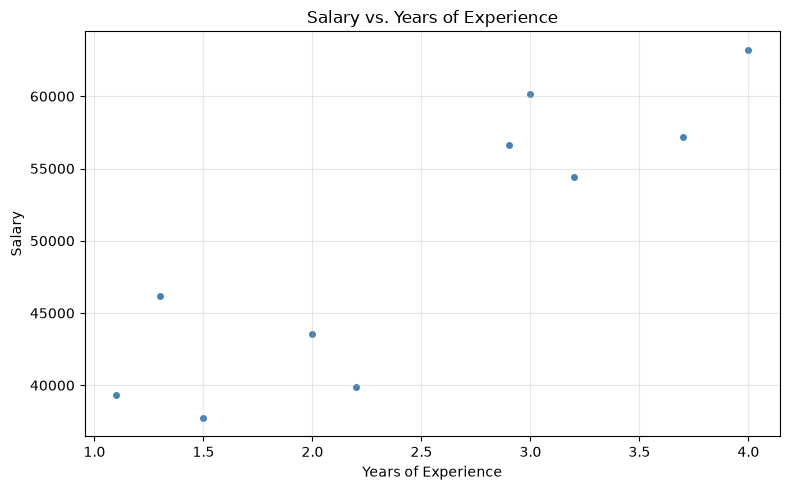

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df["YearsExperience"], df["Salary"], color="steelblue", edgecolors="white")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
X = df[["YearsExperience"]].values
y = df["Salary"].values

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept: {intercept:.2f}")
print(f"Slope: {slope:.2f}")
print(f"Regression equation: Salary = {intercept:.2f} + {slope:.2f} * YearsExperience")

Intercept: 29203.52
Slope: 8285.29
Regression equation: Salary = 29203.52 + 8285.29 * YearsExperience


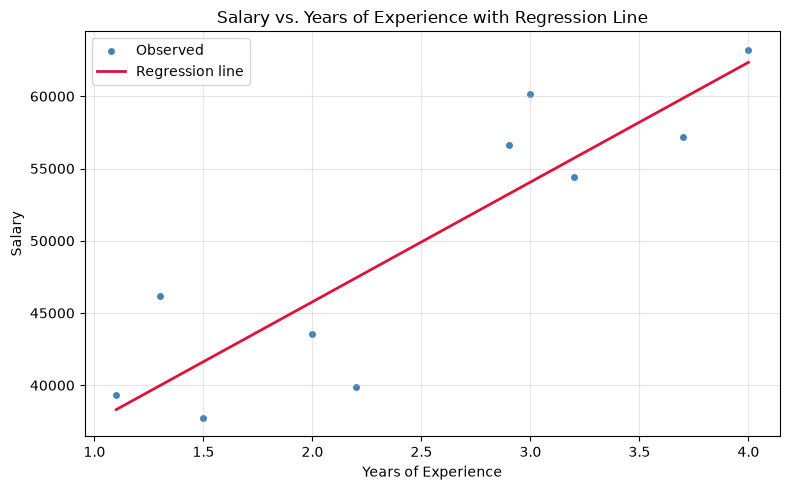

In [5]:
x_line = np.sort(df["YearsExperience"].values)
y_line = model.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(df["YearsExperience"], df["Salary"], color="steelblue", edgecolors="white", label="Observed")
plt.plot(x_line, y_line, color="crimson", linewidth=2, label="Regression line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience with Regression Line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
y_pred = model.predict(X)
residuals = y - y_pred
n = len(y)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
residual_se = np.sqrt(np.sum(residuals**2) / (n - 2))

print("Model Performance")
print("-----------------")
print(f"R-squared:              {r2:.4f}")
print(f"RMSE:                   {rmse:.2f}")
print(f"MAE:                    {mae:.2f}")
print(f"Residual Std. Error:    {residual_se:.2f}")

Model Performance
-----------------
R-squared:              0.7852
RMSE:                   4186.15
MAE:                    3526.26
Residual Std. Error:    4680.26


## Interpretation

The positive slope indicates that salary tends to increase with years of experience. R-squared shows the proportion of variance in salary explained by the linear model, while RMSE and MAE summarize typical prediction error in salary units.